# 라이브러리

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.linear_model import LinearRegression
import cv2
import seaborn as sns

# 사용자 정의 함수

## "housing" 데이터 다운로드

In [25]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

# 데이터

## 데이터 생성하기

### 데이터프레임 직접 생성하기

In [2]:
data = {
    "name": ["A", "B", "C", "D", "E", "F"],
    "sex": ["male", "female", "female", "female", "male", "male"],
    "height": ["179cm", "165cm", "160cm", "155cm", "185cm", "175cm"],
    "weight": ["80kg", "50kg", "55kg", "48kg", "100kg", "75kg"],
    "hair length": ["15cm", "30cm", "35cm", "45cm", "5cm", "3cm"],
    "temperature": ["37.5℃", "36.5℃", "36.0℃", "37.5℃", "37.0℃", "36.5℃"],
    "종교": ["무교", "불교", "불교", "기독교", "기독교", "천주교"],
    "근평": ["상", "상", "하", "중", "중", "상"],
    "머리색": ["검정", "갈색", "갈색", "검정", "검정", "녹색"]
}

df = pd.DataFrame(data)
print(df)

  name     sex height weight hair length temperature   종교 근평 머리색
0    A    male  179cm   80kg        15cm       37.5℃   무교  상  검정
1    B  female  165cm   50kg        30cm       36.5℃   불교  상  갈색
2    C  female  160cm   55kg        35cm       36.0℃   불교  하  갈색
3    D  female  155cm   48kg        45cm       37.5℃  기독교  중  검정
4    E    male  185cm  100kg         5cm       37.0℃  기독교  중  검정
5    F    male  175cm   75kg         3cm       36.5℃  천주교  상  녹색


### 데이터 가져오기

In [3]:
df = pd.read_csv("datasets/company.csv")
num,dim= df.shape
print(df)
print(num,dim)

  name     sex height weight hair length temperature   종교 근평 머리색
0    A    male  179cm   80kg        15cm       37.5℃   무교  상  검정
1    B  female  165cm   50kg        30cm       36.5℃   불교  상  갈색
2    C  female  160cm   55kg        35cm       36.0℃   불교  하  갈색
3    D  female  155cm   48kg        45cm       37.5℃  기독교  중  검정
4    E    male  185cm  100kg         5cm       37.0℃  기독교  중  검정
5    F    male  175cm   75kg         3cm       36.5℃  천주교  상  녹색
6 9


In [4]:
df["종교"] = df["종교"].map({"무교": 0, "불교": 1, "기독교": 2, "천주교": 3})

## csv 파일 가져오기

### 데이터 프레임 생성과 데이터 행렬

In [5]:
# https://archive.ics.uci.edu/dataset/53/iris -> download file

In [10]:
# 데이터 프레임 생성
df = pd.read_csv("datasets/iris.data")
num, dim = df.shape
# print(num,dim)
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
# print(df)
# 데이터 행렬과 라벨 분리
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
# print(X)
# 라벨 정보
# label =  # unique label 정보 추출
label = pd.unique(y)
print(label)

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


### 시각화

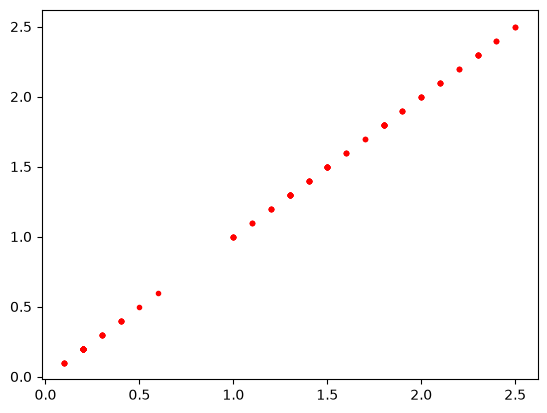

In [19]:
plt.plot(X.iloc[:, f1],X.iloc[:, f2],'r.')


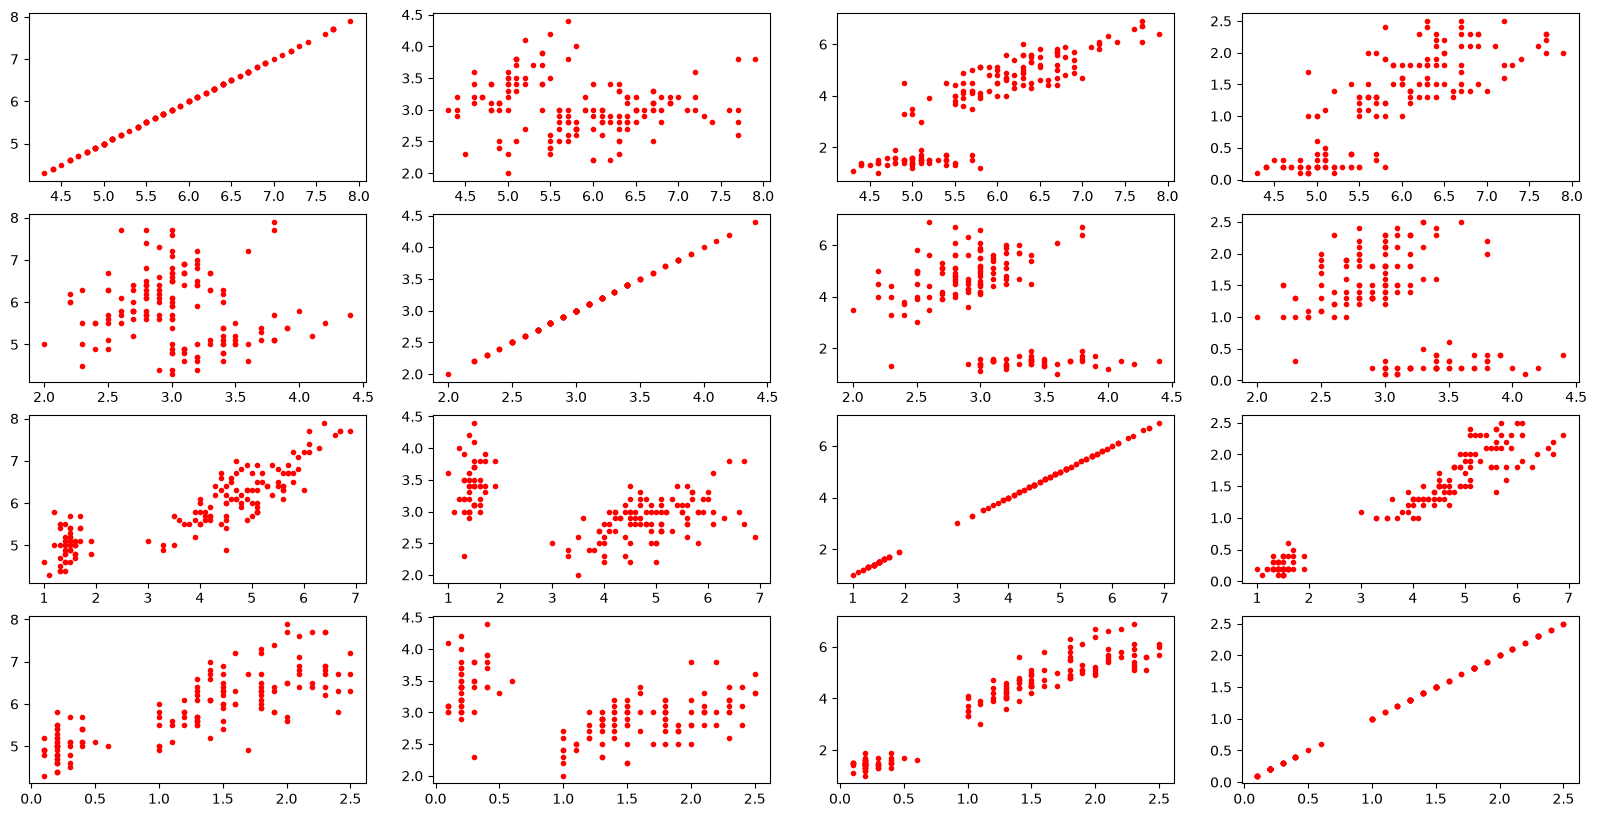

In [21]:
# 시각화
plt.figure(figsize=(20,10))
cnt = 1
for f1 in range(0,4):
    for f2 in range(0,4):
        plt.subplot(4,4,cnt)
        plt.plot(X.iloc[:, f1],X.iloc[:, f2],'r.');
        cnt +=1

plt.show()

### 시각화 - easy version

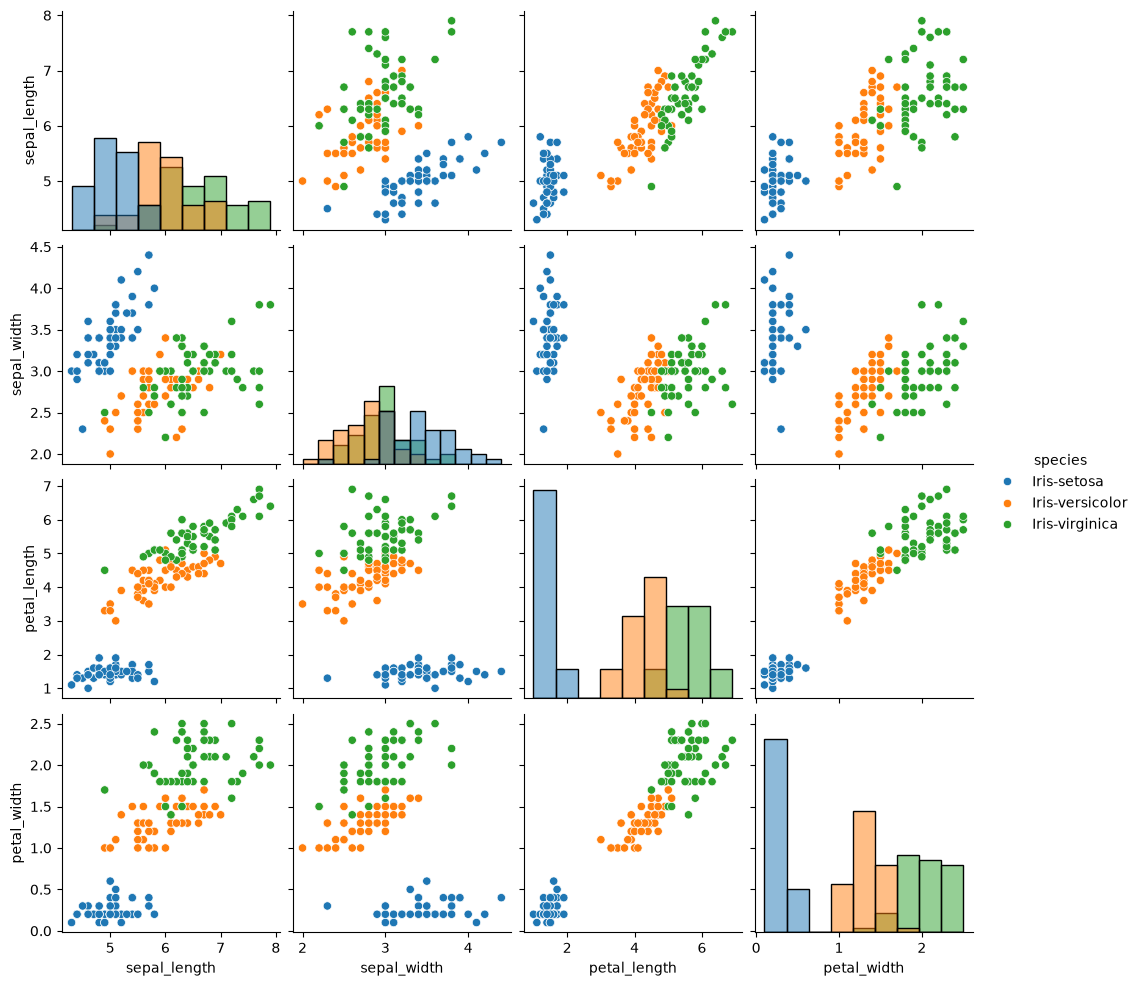

In [22]:
# pairplot
sns.pairplot(df,hue="species",diag_kind="hist")
plt.show()

### 데이터 기본 정보

#### 데이터 불러오기

In [28]:
df = load_housing_data()
num,dim = df.shape
print(num,dim)
print(df.head())

20640 10
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


#### df.info() : 데이터에 관한 간략한 설명을 보여줌

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


#### df.value_counts() : 데이터에 관한 간략한 설명을 보여줌

In [30]:
df.value_counts()

longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value  ocean_proximity
-122.23    37.88     41.0                880.0        129.0           322.0       126.0       8.3252         452600.0            NEAR BAY           1
-122.22    37.86     21.0                7099.0       1106.0          2401.0      1138.0      8.3014         358500.0            NEAR BAY           1
-122.24    37.85     52.0                1467.0       190.0           496.0       177.0       7.2574         352100.0            NEAR BAY           1
-122.25    37.85     52.0                1274.0       235.0           558.0       219.0       5.6431         341300.0            NEAR BAY           1
                                         1627.0       280.0           565.0       259.0       3.8462         342200.0            NEAR BAY           1
                                                                                                         

#### df.describe() : 숫자형 특성의 요약 정보

In [31]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### df.hist() : 전체 데이터셋에 대해 모든 숫자형 특성에 대한 히스토그램을 출력

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

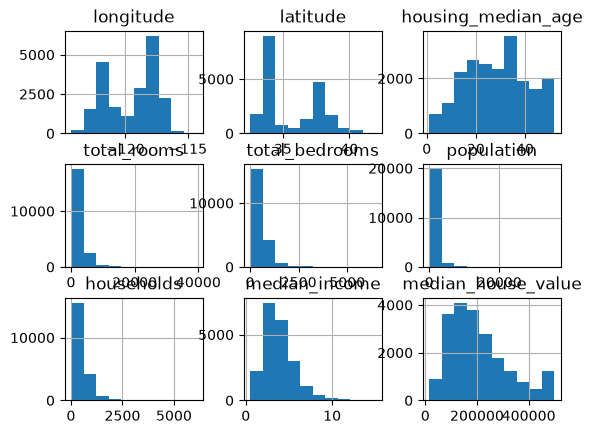

In [32]:
df.hist()

## 데이터 전처리 (preprocessing)

### 숫자형의 데이터 행렬 변환 (numeric data matrix)

#### 데이터 가져오기

In [ ]:
df = 
print(df)

#### 단위 제거 및 숫자형 변환

In [ ]:
df["height"] = 
df["weight"] = 
df["hair length"] = 
df["temperature"] = 

#### 카테코리 숫자 변환

In [ ]:
df["sex"] = 
df["종교"] = 
df["근평"] = 
df["머리색"] = 

### 제거 (elimination)

In [33]:
data = {
    "feat0": [np.nan, 8, np.nan, 7, 1],
    "feat1": [np.nan, 9, 4, 8, np.nan],
    "feat2": [5, 2, 9, 7, 2],
    "feat3": [3, 1, 8, 2, 1],
    "feat4": [np.nan, 4, 7, 4, 2],
    "feat5": [5, 5, 2, 1, 1],
    "feat6": [7, 6, 4, 1, 4],
    "feat7": [np.nan, 5, 1, np.nan, 5],
    "feat8": [9, 10, 1, 2, 6],
    "feat9": [np.nan, 5, np.nan, 1, 10],
}

df = pd.DataFrame(data)
num, dim = df.shape

print(df)

   feat0  feat1  feat2  feat3  feat4  feat5  feat6  feat7  feat8  feat9
0    NaN    NaN      5      3    NaN      5      7    NaN      9    NaN
1    8.0    9.0      2      1    4.0      5      6    5.0     10    5.0
2    NaN    4.0      9      8    7.0      2      4    1.0      1    NaN
3    7.0    8.0      7      2    4.0      1      1    NaN      2    1.0
4    1.0    NaN      2      1    2.0      1      4    5.0      6   10.0


#### 결측치(NULL)을 갖는 객체 제거

In [36]:
prep_df = df.loc[df.notna().all(axis=1)]
print(prep_df)

   feat0  feat1  feat2  feat3  feat4  feat5  feat6  feat7  feat8  feat9
1    8.0    9.0      2      1    4.0      5      6    5.0     10    5.0


#### 결측치(NULL)을 갖는 속성 제거

In [38]:
prep_df = df.loc[:,df.notna().all(axis=0)]
print(prep_df)

   feat2  feat3  feat5  feat6  feat8
0      5      3      5      7      9
1      2      1      5      6     10
2      9      8      2      4      1
3      7      2      1      1      2
4      2      1      1      4      6


### 대체, 대치 (imputation)

#### 데이터 생성하기

In [ ]:
data = {
    "feat0": [np.nan, 8, np.nan, 7, 1],
    "feat1": [np.nan, 9, 4, 8, np.nan],
    "feat2": [5, 2, 9, 7, 2],
    "feat3": [3, 1, 8, 2, 1],
    "feat4": [np.nan, 4, 7, 4, 2],
    "feat5": [5, 5, 2, 1, 1],
    "feat6": [7, 6, 4, 1, 4],
    "feat7": [np.nan, 5, 1, np.nan, 5],
    "feat8": [9, 10, 1, 2, 6],
    "feat9": [np.nan, 5, np.nan, 1, 10],
}

df = pd.DataFrame(data)
num, dim = df.shape

print(df)

#### method 1 : LOCF

In [ ]:
df_locf = df.copy()
for i in :
    for j in :
        if :    # 해당 값이 NaN이면
            
        else:
            

print(df_locf.astype("float"))

#### method 2 : NOCB

In [ ]:
df_nocb = df.copy()
for i in :
    for j in :
        if :    # 해당 값이 NaN이면
            
        else:
            

print(df_nocb.astype("float"))

#### method 3 : mean

In [ ]:
df_mean = df.copy()
for i in :
    for j in :
        if :    # 해당 값이 NaN이면
            
        else:
            

print(df_mean.astype("float"))

#### library functions

##### LOCF

In [ ]:
df_locf = 
print(df_locf)

##### NOCB

In [ ]:
df_nocb = 
print(df_nocb)

##### mean : 평균값

In [ ]:
df_mean = 
print(df_mean)

##### median : 중앙값

In [ ]:
df_median = 
print(df_median)

##### mode : 최빈값

In [ ]:
df_mode = 
print(df_mode)